In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv('mcf7_c10_p_100kb_none.txt',sep='\s+')
df.columns=['x','y','p']
df

,x,y,p
0,0,100000,88.0
1,100000,100000,73.0
2,0,200000,39.0
3,100000,200000,46.0
4,200000,200000,354.0
...,...,...,...
33332,44600000,45000000,4.0
33333,44700000,45000000,4.0
33334,44800000,45000000,9.0
33335,44900000,45000000,44.0


In [3]:
# Pivot the DataFrame to create a symmetric matrix
cont = df.pivot(index="y", columns="x", values="p")

# Make the matrix symmetric by mirroring the values
cont = cont.combine_first(cont.T)  # Fill missing values by transposing
cont=cont.fillna(0)
cont

,0,100000,200000,300000,400000,500000,600000,700000,800000,900000,...,44100000,44200000,44300000,44400000,44500000,44600000,44700000,44800000,44900000,45000000
0,0.0,88.0,39.0,46.0,23.0,25.0,24.0,17.0,12.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100000,88.0,73.0,46.0,44.0,47.0,42.0,35.0,49.0,23.0,17.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
200000,39.0,46.0,354.0,314.0,172.0,126.0,110.0,130.0,89.0,29.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
300000,46.0,44.0,314.0,743.0,412.0,225.0,203.0,226.0,131.0,40.0,...,0.0,2.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
400000,23.0,47.0,172.0,412.0,582.0,443.0,303.0,275.0,132.0,47.0,...,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44600000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,21.0,31.0,128.0,98.0,174.0,212.0,109.0,143.0,64.0,4.0
44700000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,21.0,35.0,116.0,65.0,93.0,109.0,167.0,152.0,90.0,4.0
44800000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,49.0,43.0,266.0,133.0,132.0,143.0,152.0,436.0,323.0,9.0
44900000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,...,36.0,78.0,169.0,71.0,98.0,64.0,90.0,323.0,1103.0,44.0


In [5]:
import pandas as pd

# Assuming df is your n*n matrix
df_stacked = cont.stack().reset_index()
df_stacked.columns = ['x', 'y', 'p']  # Rename columns

# Save to CSV or further processing
df_stacked.to_csv('output_3col_symmetric.csv', index=False,sep=' ')

In [4]:
df=pd.read_csv('output_3col_symmetric.csv',sep=' ')
df

,x,y,p
0,0,0,0.0
1,0,100000,88.0
2,0,200000,39.0
3,0,300000,46.0
4,0,400000,23.0
...,...,...,...
185756,45000000,44600000,4.0
185757,45000000,44700000,4.0
185758,45000000,44800000,9.0
185759,45000000,44900000,44.0


In [5]:
sum_p_by_x = df.groupby('x')['p'].sum().reset_index()
sum_p_by_x.columns = ['x', 'vc']  # Rename columns for clarity

# Display the result
print(sum_p_by_x)

            x      vc
0           0   448.0
1      100000   684.0
2      200000  1749.0
3      300000  2942.0
4      400000  2908.0
..        ...     ...
426  44600000  1375.0
427  44700000  1235.0
428  44800000  2454.0
429  44900000  2894.0
430  45000000   190.0

[431 rows x 2 columns]


In [17]:
sum_p_by_x.to_csv('mcf7_vc_data.txt',index=None,sep=' ')

In [9]:
vc=pd.read_csv('mcf7_vc_data.txt',sep=' ')
mcf7=pd.read_csv('output_3col_symmetric.csv',sep=' ')

In [10]:
mcf7

,x,y,p
0,0,0,0.0
1,0,100000,88.0
2,0,200000,39.0
3,0,300000,46.0
4,0,400000,23.0
...,...,...,...
185756,45000000,44600000,4.0
185757,45000000,44700000,4.0
185758,45000000,44800000,9.0
185759,45000000,44900000,44.0


In [11]:
max_vc = vc['vc'].max()
vc['vc']=(max_vc/vc['vc'])**(2/3)

In [12]:
vc

,x,vc
0,0,5.591253
1,100000,4.216872
2,200000,2.255111
3,300000,1.594408
4,400000,1.606811
...,...,...
426,44600000,2.647439
427,44700000,2.843914
428,44800000,1.799333
429,44900000,1.611989


In [13]:
m1=mcf7['p'].max()
m1

1826.0

In [14]:
df1=mcf7

In [15]:
df1 = df1[df1['x'] != df1['p']]
df1

,x,y,p
1,0,100000,88.0
2,0,200000,39.0
3,0,300000,46.0
4,0,400000,23.0
5,0,500000,25.0
...,...,...,...
185756,45000000,44600000,4.0
185757,45000000,44700000,4.0
185758,45000000,44800000,9.0
185759,45000000,44900000,44.0


In [16]:
df2=vc
df2

,x,vc
0,0,5.591253
1,100000,4.216872
2,200000,2.255111
3,300000,1.594408
4,400000,1.606811
...,...,...
426,44600000,2.647439
427,44700000,2.843914
428,44800000,1.799333
429,44900000,1.611989


In [17]:
ab=pd.read_csv('mcf7_none_eigen.txt',header=None,sep='\s+')
ab.columns=['i','AB']
ab['i']=(ab['i']-1)*100000
ab

,i,AB
0,0,0
1,100000,1
2,200000,0
3,300000,0
4,400000,0
...,...,...
391,39100000,1
392,39200000,1
393,39300000,1
394,39400000,1


In [18]:
vc_ab=pd.concat([vc,ab],axis=1)
vc_ab

,x,vc,i,AB
0,0,5.591253,0.0,0.0
1,100000,4.216872,100000.0,1.0
2,200000,2.255111,200000.0,0.0
3,300000,1.594408,300000.0,0.0
4,400000,1.606811,400000.0,0.0
...,...,...,...,...
426,44600000,2.647439,NaN,NaN
427,44700000,2.843914,NaN,NaN
428,44800000,1.799333,NaN,NaN
429,44900000,1.611989,NaN,NaN


In [23]:
vc_ab=vc_ab.dropna()
vc_ab

,x,vc,i,AB
0,0,5.591253,0.0,0.0
1,100000,4.216872,100000.0,1.0
2,200000,2.255111,200000.0,0.0
3,300000,1.594408,300000.0,0.0
4,400000,1.606811,400000.0,0.0
...,...,...,...,...
391,39100000,13.607337,39100000.0,1.0
392,39200000,11.061412,39200000.0,1.0
393,39300000,14.089075,39300000.0,1.0
394,39400000,17.780464,39400000.0,1.0


In [24]:
df2=vc_ab

In [25]:
merged_df=pd.merge(df1,df2,on='x',how='left')
merged_df

,x,y,p,vc,i,AB
0,0,100000,88.0,5.591253,0.0,0.0
1,0,200000,39.0,5.591253,0.0,0.0
2,0,300000,46.0,5.591253,0.0,0.0
3,0,400000,23.0,5.591253,0.0,0.0
4,0,500000,25.0,5.591253,0.0,0.0
...,...,...,...,...,...,...
185422,45000000,44600000,4.0,NaN,NaN,NaN
185423,45000000,44700000,4.0,NaN,NaN,NaN
185424,45000000,44800000,9.0,NaN,NaN,NaN
185425,45000000,44900000,44.0,NaN,NaN,NaN


In [28]:
merged_df=merged_df.dropna()
merged_df

,x,y,p,vc,i,AB
0,0,100000,88.0,5.591253,0.0,0.0
1,0,200000,39.0,5.591253,0.0,0.0
2,0,300000,46.0,5.591253,0.0,0.0
3,0,400000,23.0,5.591253,0.0,0.0
4,0,500000,25.0,5.591253,0.0,0.0
...,...,...,...,...,...,...
170337,39500000,44600000,0.0,66.185984,39500000.0,1.0
170338,39500000,44700000,0.0,66.185984,39500000.0,1.0
170339,39500000,44800000,0.0,66.185984,39500000.0,1.0
170340,39500000,44900000,0.0,66.185984,39500000.0,1.0


In [29]:
merged_df.to_csv('vc_surface_x',index=None,sep=' ')

In [30]:
merged_df=pd.read_csv('vc_surface_x',sep='\s+')
merged_df

,x,y,p,vc,i,AB
0,0,100000,88.0,5.591253,0.0,0.0
1,0,200000,39.0,5.591253,0.0,0.0
2,0,300000,46.0,5.591253,0.0,0.0
3,0,400000,23.0,5.591253,0.0,0.0
4,0,500000,25.0,5.591253,0.0,0.0
...,...,...,...,...,...,...
170337,39500000,44600000,0.0,66.185984,39500000.0,1.0
170338,39500000,44700000,0.0,66.185984,39500000.0,1.0
170339,39500000,44800000,0.0,66.185984,39500000.0,1.0
170340,39500000,44900000,0.0,66.185984,39500000.0,1.0


In [31]:
merged_df_y=pd.merge(merged_df,df2,left_on='y',right_on='x',how='left')
merged_df_y

,x_x,y,p,vc_x,i_x,AB_x,x_y,vc_y,i_y,AB_y
0,0,100000,88.0,5.591253,0.0,0.0,100000.0,4.216872,100000.0,1.0
1,0,200000,39.0,5.591253,0.0,0.0,200000.0,2.255111,200000.0,0.0
2,0,300000,46.0,5.591253,0.0,0.0,300000.0,1.594408,300000.0,0.0
3,0,400000,23.0,5.591253,0.0,0.0,400000.0,1.606811,400000.0,0.0
4,0,500000,25.0,5.591253,0.0,0.0,500000.0,1.422258,500000.0,0.0
...,...,...,...,...,...,...,...,...,...,...
170337,39500000,44600000,0.0,66.185984,39500000.0,1.0,NaN,NaN,NaN,NaN
170338,39500000,44700000,0.0,66.185984,39500000.0,1.0,NaN,NaN,NaN,NaN
170339,39500000,44800000,0.0,66.185984,39500000.0,1.0,NaN,NaN,NaN,NaN
170340,39500000,44900000,0.0,66.185984,39500000.0,1.0,NaN,NaN,NaN,NaN


In [32]:
merged_df_y=merged_df_y[['x_x','y','p','vc_x','AB_x','vc_y','AB_y']]
merged_df_y

,x_x,y,p,vc_x,AB_x,vc_y,AB_y
0,0,100000,88.0,5.591253,0.0,4.216872,1.0
1,0,200000,39.0,5.591253,0.0,2.255111,0.0
2,0,300000,46.0,5.591253,0.0,1.594408,0.0
3,0,400000,23.0,5.591253,0.0,1.606811,0.0
4,0,500000,25.0,5.591253,0.0,1.422258,0.0
...,...,...,...,...,...,...,...
170337,39500000,44600000,0.0,66.185984,1.0,NaN,NaN
170338,39500000,44700000,0.0,66.185984,1.0,NaN,NaN
170339,39500000,44800000,0.0,66.185984,1.0,NaN,NaN
170340,39500000,44900000,0.0,66.185984,1.0,NaN,NaN


In [33]:
merged_df_y=merged_df_y.dropna()

In [34]:
merged_df_y.to_csv('Score_VC_surface_coeff',index=None,sep=' ')

In [59]:
df=pd.read_csv('Score_VC_surface_coeff',sep='\s+')
df

,x_x,y,p,vc_x,AB_x,vc_y,AB_y
0,0,100000,88.0,5.591253,0.0,4.216872,1.0
1,0,200000,39.0,5.591253,0.0,2.255111,0.0
2,0,300000,46.0,5.591253,0.0,1.594408,0.0
3,0,400000,23.0,5.591253,0.0,1.606811,0.0
4,0,500000,25.0,5.591253,0.0,1.422258,0.0
...,...,...,...,...,...,...,...
156508,39500000,39100000,1.0,66.185984,1.0,13.607337,1.0
156509,39500000,39200000,0.0,66.185984,1.0,11.061412,1.0
156510,39500000,39300000,1.0,66.185984,1.0,14.089075,1.0
156511,39500000,39400000,1.0,66.185984,1.0,17.780464,1.0


In [60]:
def calculate_score(row):
    if row['AB_x'] == 1 and row['AB_y'] == 1:
        return row['p'] * row['vc_x'] * row['vc_y']
    elif row['AB_x'] == 0 and row['AB_y'] == 1:
        return row['p'] * row['vc_y']
    elif row['AB_x'] == 1 and row['AB_y'] == 0:
        return row['p'] * row['vc_x']
    else:
        return row['p']

df['score'] = df.apply(calculate_score, axis=1)
df

,x_x,y,p,vc_x,AB_x,vc_y,AB_y,score
0,0,100000,88.0,5.591253,0.0,4.216872,1.0,371.084738
1,0,200000,39.0,5.591253,0.0,2.255111,0.0,39.000000
2,0,300000,46.0,5.591253,0.0,1.594408,0.0,46.000000
3,0,400000,23.0,5.591253,0.0,1.606811,0.0,23.000000
4,0,500000,25.0,5.591253,0.0,1.422258,0.0,25.000000
...,...,...,...,...,...,...,...,...
156508,39500000,39100000,1.0,66.185984,1.0,13.607337,1.0,900.615012
156509,39500000,39200000,0.0,66.185984,1.0,11.061412,1.0,0.000000
156510,39500000,39300000,1.0,66.185984,1.0,14.089075,1.0,932.499280
156511,39500000,39400000,1.0,66.185984,1.0,17.780464,1.0,1176.817521


In [61]:
df.dtypes

x_x        int64
y          int64
p        float64
vc_x     float64
AB_x     float64
vc_y     float64
AB_y     float64
score    float64
dtype: object

In [62]:
df['vc_x'] = pd.to_numeric(df['vc_x'], errors='coerce')
df['vc_y'] = pd.to_numeric(df['vc_y'], errors='coerce')

In [63]:
df

,x_x,y,p,vc_x,AB_x,vc_y,AB_y,score
0,0,100000,88.0,5.591253,0.0,4.216872,1.0,371.084738
1,0,200000,39.0,5.591253,0.0,2.255111,0.0,39.000000
2,0,300000,46.0,5.591253,0.0,1.594408,0.0,46.000000
3,0,400000,23.0,5.591253,0.0,1.606811,0.0,23.000000
4,0,500000,25.0,5.591253,0.0,1.422258,0.0,25.000000
...,...,...,...,...,...,...,...,...
156508,39500000,39100000,1.0,66.185984,1.0,13.607337,1.0,900.615012
156509,39500000,39200000,0.0,66.185984,1.0,11.061412,1.0,0.000000
156510,39500000,39300000,1.0,66.185984,1.0,14.089075,1.0,932.499280
156511,39500000,39400000,1.0,66.185984,1.0,17.780464,1.0,1176.817521


In [64]:
df['enrichment']=df['score']-df['p']

In [65]:
df

,x_x,y,p,vc_x,AB_x,vc_y,AB_y,score,enrichment
0,0,100000,88.0,5.591253,0.0,4.216872,1.0,371.084738,283.084738
1,0,200000,39.0,5.591253,0.0,2.255111,0.0,39.000000,0.000000
2,0,300000,46.0,5.591253,0.0,1.594408,0.0,46.000000,0.000000
3,0,400000,23.0,5.591253,0.0,1.606811,0.0,23.000000,0.000000
4,0,500000,25.0,5.591253,0.0,1.422258,0.0,25.000000,0.000000
...,...,...,...,...,...,...,...,...,...
156508,39500000,39100000,1.0,66.185984,1.0,13.607337,1.0,900.615012,899.615012
156509,39500000,39200000,0.0,66.185984,1.0,11.061412,1.0,0.000000,0.000000
156510,39500000,39300000,1.0,66.185984,1.0,14.089075,1.0,932.499280,931.499280
156511,39500000,39400000,1.0,66.185984,1.0,17.780464,1.0,1176.817521,1175.817521


In [ ]:
df['enrichment_2']=df['score_scaled']-df['p']

In [68]:
df.head()

,x_x,y,p,vc_x,AB_x,vc_y,AB_y,score,enrichment
0,0,100000,88.0,5.591253,0.0,4.216872,1.0,371.084738,283.084738
1,0,200000,39.0,5.591253,0.0,2.255111,0.0,39.000000,0.000000
2,0,300000,46.0,5.591253,0.0,1.594408,0.0,46.000000,0.000000
3,0,400000,23.0,5.591253,0.0,1.606811,0.0,23.000000,0.000000
4,0,500000,25.0,5.591253,0.0,1.422258,0.0,25.000000,0.000000


In [69]:
df.to_csv('modified_score_enrichment',index=None,sep=' ')

In [70]:
df.corr()

,x_x,y,p,vc_x,AB_x,vc_y,AB_y,score,enrichment
x_x,1.000000,0.000674,-0.059528,0.332187,0.182877,0.000380,0.000539,0.019337,0.035139
y,0.000674,1.000000,-0.058897,-0.000106,0.000449,0.330386,0.186150,0.019937,0.035637
p,-0.059528,-0.058897,1.000000,-0.047357,-0.058277,-0.047453,-0.057910,0.439204,0.236119
vc_x,0.332187,-0.000106,-0.047357,1.000000,0.327396,-0.000060,-0.000085,0.023079,0.036279
AB_x,0.182877,0.000449,-0.058277,0.327396,1.000000,0.000253,0.000359,0.090349,0.111649
vc_y,0.000380,0.330386,-0.047453,-0.000060,0.000253,1.000000,0.326414,0.023052,0.036272
AB_y,0.000539,0.186150,-0.057910,-0.000085,0.000359,0.326414,1.000000,0.090752,0.111997
score,0.019337,0.019937,0.439204,0.023079,0.090349,0.023052,0.090752,1.000000,0.976689
enrichment,0.035139,0.035637,0.236119,0.036279,0.111649,0.036272,0.111997,0.976689,1.000000


[]

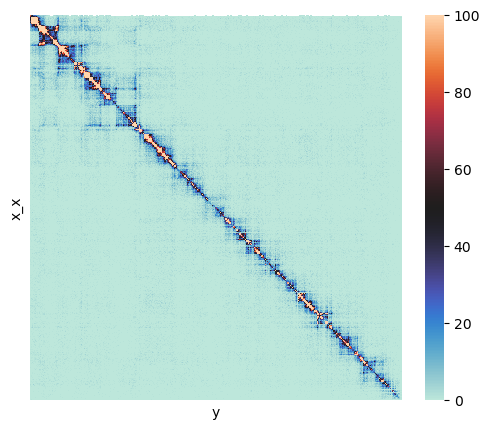

In [74]:
import seaborn as sns
cont=df.pivot('x_x','y','p')
plt.subplots(figsize=(6,5))
display=sns.heatmap(cont,cmap='icefire',vmin=0.0,vmax=100.0,cbar=True)
display.set_xticks([])
display.set_yticks([])

[]

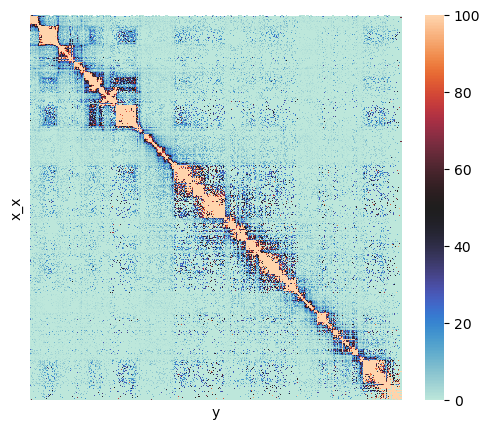

In [75]:
cont=df.pivot('x_x','y','score')
plt.subplots(figsize=(6,5))
display=sns.heatmap(cont,cmap='icefire',vmin=0.0,vmax=100.0,cbar=True)
display.set_xticks([])
display.set_yticks([])

In [50]:
df=pd.read_csv('modified_score_enrichment',sep='\s+')
df

,x_x,y,p,vc_x,AB_x,vc_y,AB_y,score,enrichment
0,0,100000,88.0,5.591253,0.0,4.216872,1.0,371.084738,283.084738
1,0,200000,39.0,5.591253,0.0,2.255111,0.0,39.000000,0.000000
2,0,300000,46.0,5.591253,0.0,1.594408,0.0,46.000000,0.000000
3,0,400000,23.0,5.591253,0.0,1.606811,0.0,23.000000,0.000000
4,0,500000,25.0,5.591253,0.0,1.422258,0.0,25.000000,0.000000
...,...,...,...,...,...,...,...,...,...
156508,39500000,39100000,1.0,66.185984,1.0,13.607337,1.0,900.615012,899.615012
156509,39500000,39200000,0.0,66.185984,1.0,11.061412,1.0,0.000000,0.000000
156510,39500000,39300000,1.0,66.185984,1.0,14.089075,1.0,932.499280,931.499280
156511,39500000,39400000,1.0,66.185984,1.0,17.780464,1.0,1176.817521,1175.817521


In [52]:
df=df[['x_x','y','score']]
df.columns=['x','y','score']

In [53]:
df

,x,y,score
0,0,100000,371.084738
1,0,200000,39.000000
2,0,300000,46.000000
3,0,400000,23.000000
4,0,500000,25.000000
...,...,...,...
156508,39500000,39100000,900.615012
156509,39500000,39200000,0.000000
156510,39500000,39300000,932.499280
156511,39500000,39400000,1176.817521


In [54]:
df.to_csv('chr10_N_scaled_score',index=None,sep=' ')

In [55]:
df['Value1'] = 0
df['Value2'] = 0
df['Value3'] = 0
df['Value4'] = 1
df['Value5'] = 10
df['Value1'] = df['Value1'].astype(int)
df['Value2'] = df['Value2'].astype(int)
df['Value3'] = df['Value3'].astype(int)
df['Value4'] = df['Value4'].astype(int)
df['Value5'] = df['Value5'].astype(int)
df = df[['Value1','Value5', 'x','Value2' ,'Value3','Value5','y','Value4','score']]

/home/swayamshree/.local/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/home/swayamshree/.local/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/swayamshree/.local/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

In [56]:
df1=pd.DataFrame(df)
df1

,Value1,Value5,x,Value2,Value3,Value5,y,Value4,score
0,0,10,0,0,0,10,100000,1,371.084738
1,0,10,0,0,0,10,200000,1,39.000000
2,0,10,0,0,0,10,300000,1,46.000000
3,0,10,0,0,0,10,400000,1,23.000000
4,0,10,0,0,0,10,500000,1,25.000000
...,...,...,...,...,...,...,...,...,...
156508,0,10,39500000,0,0,10,39100000,1,900.615012
156509,0,10,39500000,0,0,10,39200000,1,0.000000
156510,0,10,39500000,0,0,10,39300000,1,932.499280
156511,0,10,39500000,0,0,10,39400000,1,1176.817521


In [57]:
df1.to_csv('norm_output_pre_format_for_juicer',index=None,sep=' ')

In [5]:
import pandas as pd
df=pd.read_csv('mcf7_c10_p_100kb_norm.txt',sep='\s+')
df.columns=['x','y','p']

In [6]:
df

,x,y,p
0,100000,100000,995.937744
1,0,200000,1023.577698
2,100000,200000,702.338318
3,200000,200000,1512.206055
4,0,300000,786.844421
...,...,...,...
78599,39100000,39500000,1379.510010
78600,39200000,39500000,0.000000
78601,39300000,39500000,1481.756348
78602,39400000,39500000,2178.601562


In [8]:
# import seaborn as sns
# cont=df.pivot('x','y','p')
# cont=cont.T()
# plt.subplots(figsize=(6,5))
# display=sns.heatmap(cont,cmap='icefire',vmin=0.0,vmax=100.0,cbar=True)
# display.set_xticks([])
# display.set_yticks([])

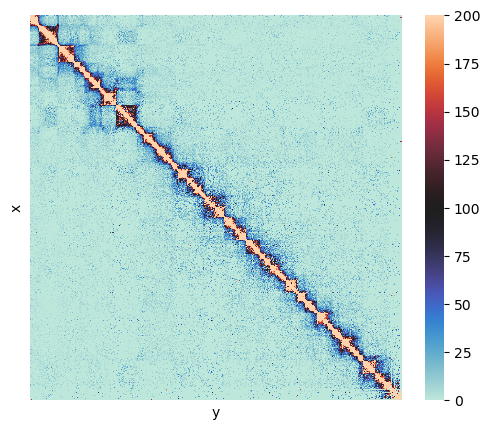

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot to wide format
cont = df.pivot(index='x', columns='y', values='p')

# Reindex to make it square
common_index = sorted(set(cont.index).union(set(cont.columns)))
cont = cont.reindex(index=common_index, columns=common_index)

# Fill missing values with 0 or any default
cont = cont.fillna(0)

# Make the matrix symmetric using the average with its transpose
cont_sym = (cont + cont.T) / 2

# Plot the symmetric heatmap
plt.subplots(figsize=(6, 5))
display = sns.heatmap(cont_sym, cmap='icefire', vmin=0.0, vmax=200.0, cbar=True)

# Remove ticks
display.set_xticks([])
display.set_yticks([])

plt.show()
